In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!unzip Fake.csv.zip
!unzip True.csv.zip

Archive:  Fake.csv.zip
  inflating: Fake.csv                
Archive:  True.csv.zip
  inflating: True.csv                


In [ ]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake["label"] = 0
true["label"] = 1

In [ ]:
data = pd.concat([fake, true])

In [ ]:
data = data.sample(frac=1).reset_index(drop=True)

In [ ]:
data.head()

,title,text,subject,date,label
0,"U.S. urges Myanmar to stop offensive, allow ci...",UNITED NATIONS (Reuters) - The United States u...,worldnews,"September 18, 2017",1
1,Ron Paul Liberty Report: US-Saudi Arms Traffic...,"Back in July, 21WIRE detailed the investigativ...",Middle-east,"September 19, 2017",0
2,GERMAN RESIDENTS FIGHT BACK: Anti-Islamic Song...,Apparently these Germans are not interested in...,Government News,"Jan 3, 2016",0
3,Trump nominates White House aide for homeland ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"October 11, 2017",1
4,NRA opposes outright U.S. ban on gun devices u...,WASHINGTON (Reuters) - The powerful U.S. gun l...,politicsNews,"October 8, 2017",1


In [ ]:
data["label"].value_counts()

,count
label,
0,23481
1,21417


In [ ]:
data["content"] = data["title"] + " " + data["text"]

In [ ]:
data = data[["content", "label"]]

In [ ]:
data.head()

,content,label
0,"U.S. urges Myanmar to stop offensive, allow ci...",1
1,Ron Paul Liberty Report: US-Saudi Arms Traffic...,0
2,GERMAN RESIDENTS FIGHT BACK: Anti-Islamic Song...,0
3,Trump nominates White House aide for homeland ...,1
4,NRA opposes outright U.S. ban on gun devices u...,1


In [ ]:
print(data["content"][0])

U.S. urges Myanmar to stop offensive, allow civilians to return UNITED NATIONS (Reuters) - The United States urged the Myanmar government on Monday to end military operations in Rakhine state, grant humanitarian access, and commit to aiding the safe return of civilians to their homes, said U.S. Ambassador to the U.N. Nikki Haley.   People are still at risk of being attacked or killed, humanitarian aid is not reaching the people who need it, and innocent civilians are still fleeing across the border to Bangladesh,  Haley said in a statement. Haley s remarks came after she attended a ministerial meeting hosted by British Foreign Secretary Boris Johnson on Myanmar on the sidelines of the U.N. General Assembly. 


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    data["content"].tolist(),
    data["label"].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
print(len(train_texts))
print(len(val_texts))

35918
8980


In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
tokenizer(train_texts[0])

{'input_ids': [101, 7987, 10288, 4183, 7566, 3685, 2693, 2000, 4403, 1016, 2302, 3675, 15563, 1010, 3163, 2758, 5772, 1006, 26665, 1007, 1011, 3725, 1055, 7566, 2006, 22371, 1996, 2647, 2586, 3685, 5082, 1010, 2004, 2414, 8996, 1010, 2000, 3104, 3119, 4262, 2127, 2009, 3957, 2062, 15563, 2006, 2054, 2097, 4148, 2012, 1996, 3675, 2007, 3163, 1010, 3493, 3097, 2704, 4079, 25248, 3240, 2056, 2006, 5958, 1012, 2006, 1996, 3675, 3277, 1010, 1045, 1049, 3374, 2021, 2057, 2342, 2062, 15563, 2084, 2057, 2031, 2157, 2085, 1012, 2057, 3685, 2693, 3805, 2000, 4403, 1016, 2006, 1996, 2067, 1997, 1037, 4872, 2008, 2057, 2123, 1056, 2156, 2151, 6959, 7337, 2000, 2191, 1037, 4507, 1010, 25248, 3240, 2409, 1037, 3034, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=512
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=512
)

In [ ]:
print(train_encodings.keys())

Buffered data was truncated after reaching the output size limit.

In [23]:
list(train_encodings.keys())

['input_ids', 'attention_mask']

In [24]:
len(train_encodings["input_ids"])

35918

In [25]:
class FakeNewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [26]:
train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset = FakeNewsDataset(val_encodings, val_labels)

In [27]:
len(train_dataset)

35918

In [28]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [31]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs",
    logging_steps=100,
    save_steps=500
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [32]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [33]:
 trainer.train()

Step,Training Loss
100,0.113598
200,0.019332
300,0.000379
400,0.028220
500,0.021045
600,0.000138
700,0.023057
800,0.012933
900,0.014161
1000,0.009220


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8980, training_loss=0.006744337743074962, metrics={'train_runtime': 4387.0817, 'train_samples_per_second': 16.374, 'train_steps_per_second': 2.047, 'total_flos': 9515928049852416.0, 'train_loss': 0.006744337743074962, 'epoch': 2.0})

In [34]:
trainer.save_model("fake_news_distilbert")
tokenizer.save_pretrained("fake_news_distilbert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_distilbert/tokenizer_config.json',
 'fake_news_distilbert/tokenizer.json')

In [36]:
!zip -r fake_news_distilbert.zip fake_news_distilbert

  adding: fake_news_distilbert/ (stored 0%)
  adding: fake_news_distilbert/tokenizer_config.json (deflated 42%)
  adding: fake_news_distilbert/tokenizer.json (deflated 71%)
  adding: fake_news_distilbert/model.safetensors (deflated 8%)
  adding: fake_news_distilbert/config.json (deflated 49%)
  adding: fake_news_distilbert/training_args.bin (deflated 53%)


In [37]:
from google.colab import files
files.download("fake_news_distilbert.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import numpy as np

predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(val_labels, preds)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [40]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4741
           1       1.00      1.00      1.00      4239

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



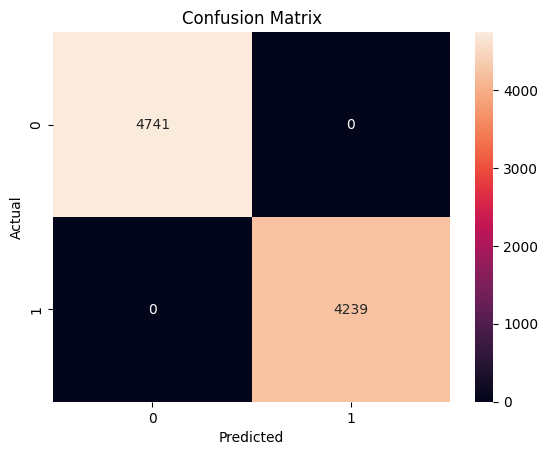

In [41]:
cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [42]:
wrong = []

for i in range(len(preds)):
    if preds[i] != val_labels[i]:
        wrong.append((val_texts[i], preds[i], val_labels[i]))

len(wrong)

0

In [43]:
import torch

def predict_news(text):

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)

    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    prediction = torch.argmax(logits, dim=1).item()

    if prediction == 0:
        return "Fake News"
    else:
        return "Real News"

In [44]:
predict_news("Breaking: Government announces new economic policy to improve employment rates")

'Real News'

In [45]:
predict_news("Shocking! Scientists confirm aliens secretly control the world government")

'Fake News'

In [46]:
import torch.nn.functional as F

def predict_news_with_confidence(text):

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = F.softmax(logits, dim=1)

    confidence, prediction = torch.max(probs, dim=1)

    label = "Fake News" if prediction.item() == 0 else "Real News"

    return label, confidence.item()

In [47]:
predict_news_with_confidence("Breaking: Government announces new tax reforms for businesses")

('Real News', 0.973334550857544)

In [48]:
!pip install gradio

In [49]:
import gradio as gr

def fake_news_detector(text):
    label, confidence = predict_news_with_confidence(text)
    return f"{label} (Confidence: {confidence*100:.2f}%)"

interface = gr.Interface(
    fn=fake_news_detector,
    inputs=gr.Textbox(lines=5, placeholder="Enter news text here..."),
    outputs="text",
    title="Fake News Detection using DistilBERT",
    description="Enter a news headline or article to check if it is Fake or Real."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b65bfe2d12c44c241.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
